# Phase 2: Analysis and Reverse Engineering

This notebook walks through Phase 2 analysis:
1. Algorithm Profiling
2. Benchmark Reverse Engineering
3. Asset Inference (what assets do algorithms trade?)
4. Investment Clock Regime Inference
5. Correlation Analysis

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

%matplotlib inline

In [4]:
# Load Phase 1 data
from src.utils.paths import data_paths
from notebook_paths import notebook_data_path
dp = data_paths()

# Backward-compatible aliases
PROCESSED_PATH = notebook_data_path()
PHASE2_PATH = PROCESSED_PATH / 'phase2'
PHASE2_PATH.mkdir(parents=True, exist_ok=True)

# Returns matrix
returns_matrix = pd.read_parquet(notebook_data_path('algo_returns.parquet'))
print(f"Returns matrix: {returns_matrix.shape}")

# Benchmark returns
bench_returns = pd.read_csv(notebook_data_path('benchmark_daily_returns.csv'), index_col=0, parse_dates=True)
if 'return' in bench_returns.columns:
    bench_returns = bench_returns['return']
else:
    bench_returns = bench_returns.iloc[:, 0]
print(f"Benchmark returns: {len(bench_returns)} days")

# Benchmark weights (if available)
weights_path = notebook_data_path('benchmark_weights.parquet')
if weights_path.exists():
    bench_weights = pd.read_parquet(weights_path)
    print(f"Benchmark weights: {bench_weights.shape}")
else:
    bench_weights = None
    print("Benchmark weights not available")

Returns matrix: (1430, 13513)
Benchmark returns: 1429 days
Benchmark weights: (1956, 271)


---
## 1. Algorithm Profiling

Profile each algorithm with performance, risk, and operational metrics.

In [5]:
from src.analysis.algo_profiler import AlgoProfiler

profiler = AlgoProfiler()

# Sample for speed (use all for production)
sample_size = min(100, len(returns_matrix.columns))
sample_cols = returns_matrix.columns[:sample_size]
returns_sample = returns_matrix[sample_cols]

print(f"Profiling {sample_size} algorithms...")
profiles = profiler.profile_all(returns_sample, benchmark_returns=bench_returns)
print(f"Profiled {len(profiles)} algorithms")

Profiled 100 algorithms


In [6]:
# Generate summary table
summary_df = profiler.generate_summary_table(profiles)
print("Algorithm Profile Summary:")
display(summary_df.head(10))

,ann_return,ann_volatility,sharpe,sortino,calmar,max_dd,max_dd_days,var_95,cvar_95,corr_benchmark
algo_id,,,,,,,,,,
RNLWE,0.021584,0.124515,0.233864,0.224411,0.090138,-0.239451,505,-0.010370,-0.018989,0.159804
bpN6K,0.037524,0.026335,1.411550,1.629419,7.325077,-0.005123,9,-0.002398,-0.002410,-0.434643
kfqHw,-0.099024,0.099410,-0.998858,-0.817636,-0.219679,-0.450765,774,-0.011085,-0.017384,-0.023100
6EP4q,0.015300,0.063449,0.271149,0.141744,0.141170,-0.108384,232,-0.009135,-0.012864,0.046227
SwuqV,0.161073,0.124956,1.257369,0.844730,2.182343,-0.073808,119,-0.008785,-0.016661,0.280072
cGjAx,-0.003753,0.122287,0.029724,0.035612,-0.022554,-0.166394,568,-0.009757,-0.014402,0.260734
PCQP4,0.057120,0.126758,0.501344,0.447076,0.457093,-0.124963,168,-0.013140,-0.019175,0.096353
hOJYz,0.126769,0.109338,1.146384,1.072326,1.265394,-0.100181,274,-0.008941,-0.015537,0.091558
u9rnm,0.090013,0.127297,0.740358,0.769389,0.487204,-0.184755,780,-0.008742,-0.017906,-0.005071


In [7]:
# Top algorithms by Sharpe
print("\nTop 10 by Sharpe Ratio:")
top_sharpe = summary_df.nlargest(10, 'sharpe')[['sharpe', 'ann_return', 'ann_volatility', 'max_dd']]
display(top_sharpe)

,sharpe,ann_return,ann_volatility,max_dd
algo_id,,,,
ftSR7,2.156438,0.188046,0.081439,-0.025315
Pfmpa,2.070309,0.237114,0.105478,-0.047529
oJmyp,2.001598,0.198209,0.092504,-0.052548
A7uuZ,1.986383,0.174301,0.082615,-0.026153
bpN6K,1.411550,0.037524,0.026335,-0.005123
ZkS39,1.411388,0.162044,0.110790,-0.070485
eACAc,1.360276,0.198986,0.140673,-0.075830
vgCD1,1.326008,0.151784,0.111199,-0.096715
3TNyD,1.270829,0.129067,0.099418,-0.068296


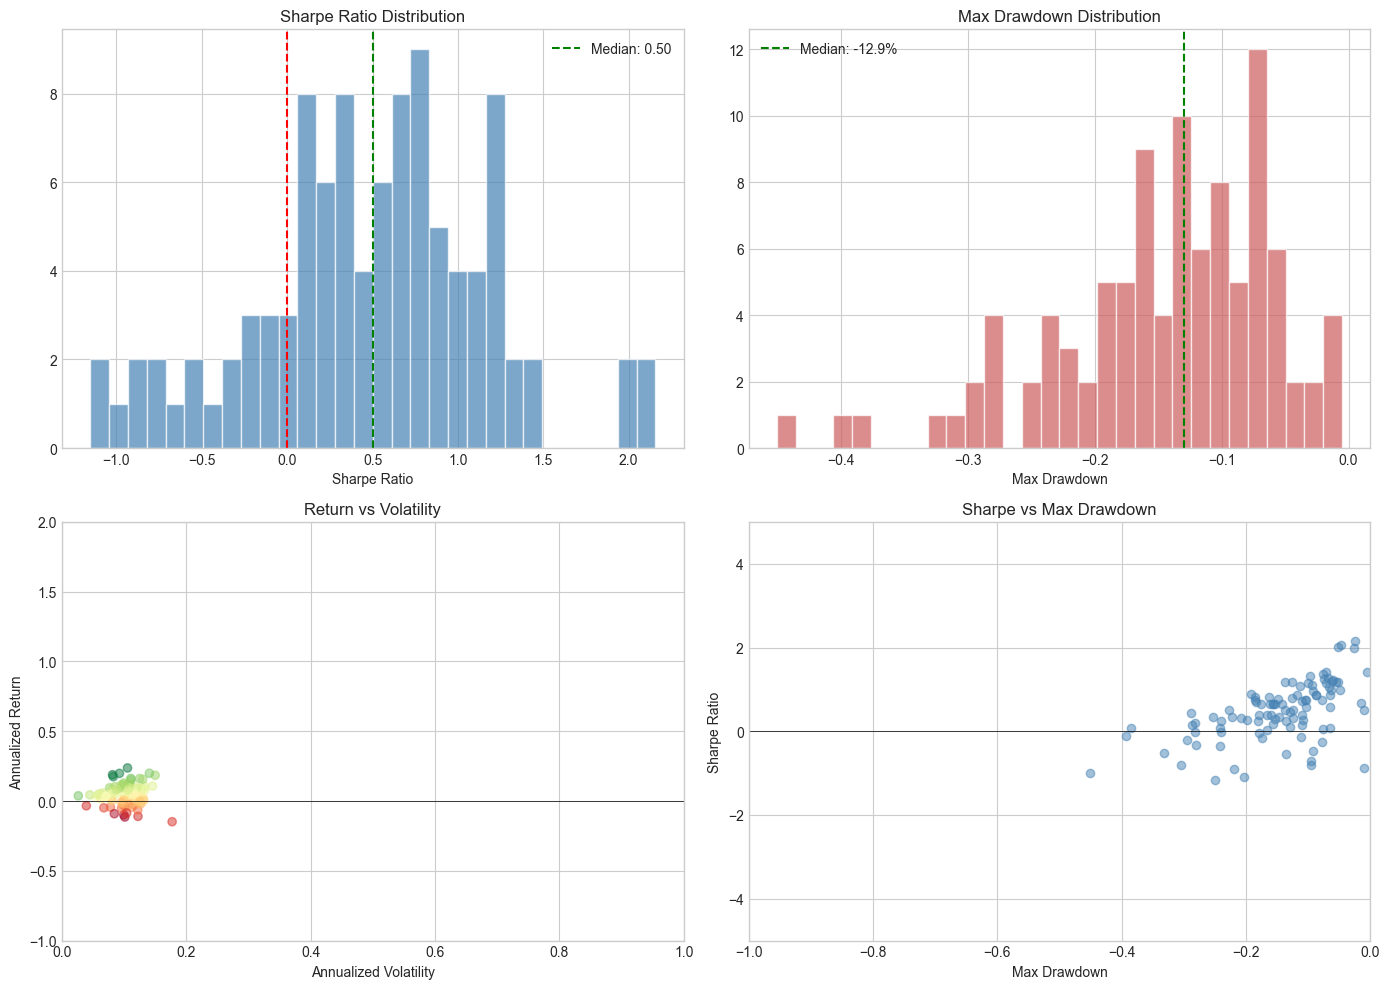

In [8]:
# Visualize performance distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sharpe distribution
sharpe_vals = summary_df['sharpe'].dropna()
sharpe_vals = sharpe_vals[np.isfinite(sharpe_vals)]
axes[0, 0].hist(sharpe_vals.clip(-5, 5), bins=30, alpha=0.7, color='steelblue', edgecolor='white')
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].axvline(x=sharpe_vals.median(), color='green', linestyle='--', label=f'Median: {sharpe_vals.median():.2f}')
axes[0, 0].set_title('Sharpe Ratio Distribution')
axes[0, 0].set_xlabel('Sharpe Ratio')
axes[0, 0].legend()

# Max Drawdown distribution
dd_vals = summary_df['max_dd'].dropna()
axes[0, 1].hist(dd_vals.clip(-1, 0), bins=30, alpha=0.7, color='indianred', edgecolor='white')
axes[0, 1].axvline(x=dd_vals.median(), color='green', linestyle='--', label=f'Median: {dd_vals.median():.1%}')
axes[0, 1].set_title('Max Drawdown Distribution')
axes[0, 1].set_xlabel('Max Drawdown')
axes[0, 1].legend()

# Return vs Volatility scatter
axes[1, 0].scatter(summary_df['ann_volatility'], summary_df['ann_return'], 
                   alpha=0.5, c=summary_df['sharpe'].clip(-3, 3), cmap='RdYlGn')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_title('Return vs Volatility')
axes[1, 0].set_xlabel('Annualized Volatility')
axes[1, 0].set_ylabel('Annualized Return')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(-1, 2)

# Sharpe vs Max DD scatter
axes[1, 1].scatter(summary_df['max_dd'], summary_df['sharpe'], alpha=0.5, color='steelblue')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_title('Sharpe vs Max Drawdown')
axes[1, 1].set_xlabel('Max Drawdown')
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].set_xlim(-1, 0)
axes[1, 1].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

---
## 2. Benchmark Reverse Engineering

Understand the benchmark's allocation strategy.

In [9]:
from src.analysis.benchmark_profiler import BenchmarkProfiler

bench_profiler = BenchmarkProfiler()

# Create synthetic weights if not available
if bench_weights is None:
    print("Creating equal-weight synthetic weights...")
    bench_weights = pd.DataFrame(
        1.0 / len(returns_matrix.columns),
        index=returns_matrix.index,
        columns=returns_matrix.columns
    )

# Profile benchmark
bench_profile = bench_profiler.profile(returns=bench_returns, weights=bench_weights)
print("Benchmark profiled.")

Benchmark profiled.


In [10]:
# Display benchmark profile
print("BENCHMARK PROFILE")
print("=" * 50)
print(f"Annualized Return: {bench_profile.annualized_return:.2%}")
print(f"Annualized Volatility: {bench_profile.annualized_volatility:.2%}")
print(f"Sharpe Ratio: {bench_profile.sharpe_ratio:.2f}")
print(f"Sortino Ratio: {bench_profile.sortino_ratio:.2f}")
print(f"Max Drawdown: {bench_profile.max_drawdown:.2%}")
print(f"Max DD Duration: {bench_profile.max_drawdown_duration} days")
print(f"\nALLOCATION POLICY")
print(f"Concentration (HHI): {bench_profile.concentration_hhi:.4f}")
print(f"Avg Concentration: {bench_profile.concentration_hhi_avg:.4f}")
print(f"Turnover (annualized): {bench_profile.turnover_annualized:.2%}")
print(f"Rebalance Freq: every {bench_profile.rebalance_frequency_days:.0f} days")
print(f"Avg Holding Period: {bench_profile.avg_holding_period_days:.0f} days")

BENCHMARK PROFILE
Annualized Return: 2.59%
Annualized Volatility: 2.73%
Sharpe Ratio: 0.95
Sortino Ratio: 1.43
Max Drawdown: -2.60%
Max DD Duration: 248 days

ALLOCATION POLICY
Concentration (HHI): 0.0626
Avg Concentration: 0.0475
Turnover (annualized): 418.49%
Rebalance Freq: every 2 days
Avg Holding Period: 4 days


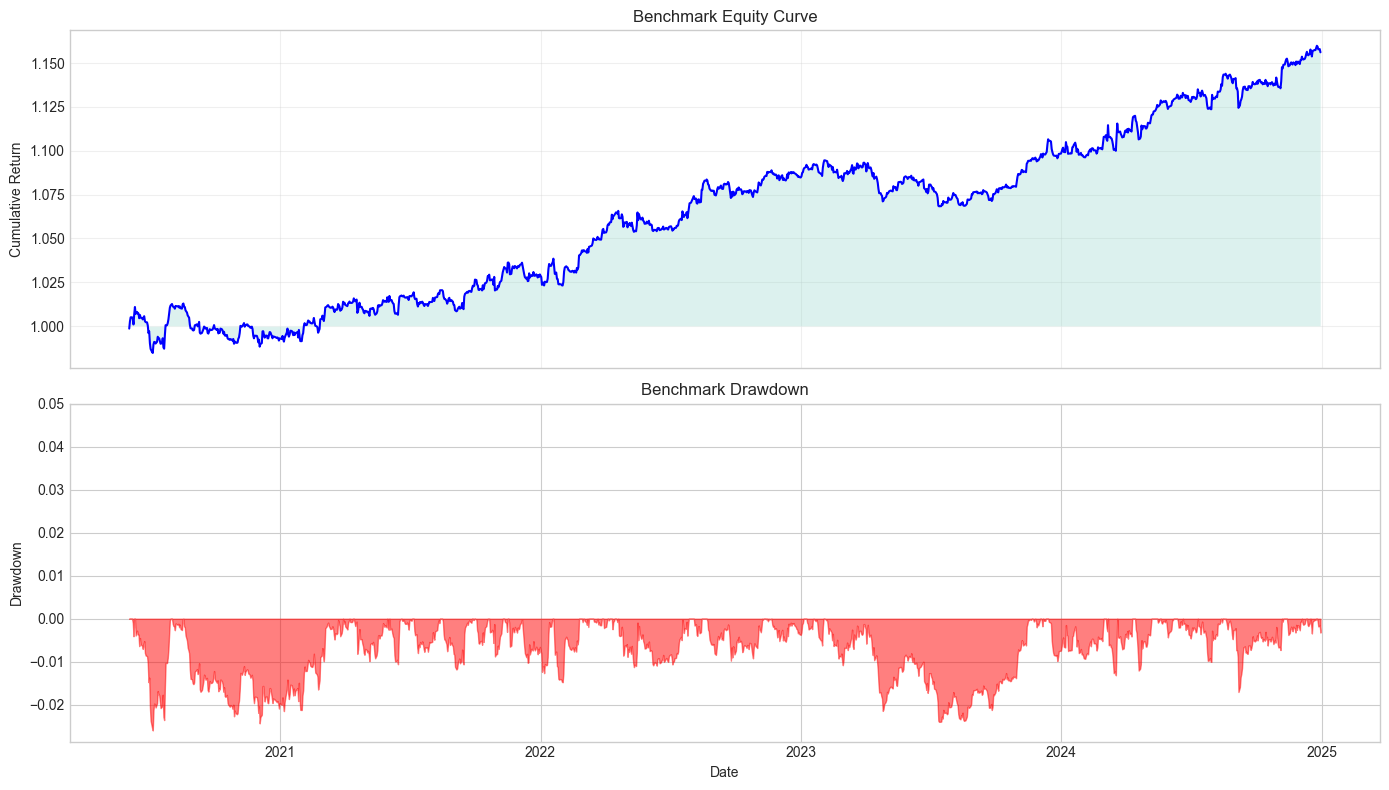

In [11]:
# Benchmark equity curve and drawdown
bench_equity = (1 + bench_returns).cumprod()
bench_drawdown = bench_equity / bench_equity.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Equity curve
axes[0].plot(bench_equity.index, bench_equity.values, 'b-', linewidth=1.5)
axes[0].fill_between(bench_equity.index, 1, bench_equity.values, alpha=0.3)
axes[0].set_title('Benchmark Equity Curve')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(True, alpha=0.3)

# Drawdown
axes[1].fill_between(bench_drawdown.index, 0, bench_drawdown.values, color='red', alpha=0.5)
axes[1].set_title('Benchmark Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].set_ylim(bench_drawdown.min() * 1.1, 0.05)

plt.tight_layout()
plt.show()

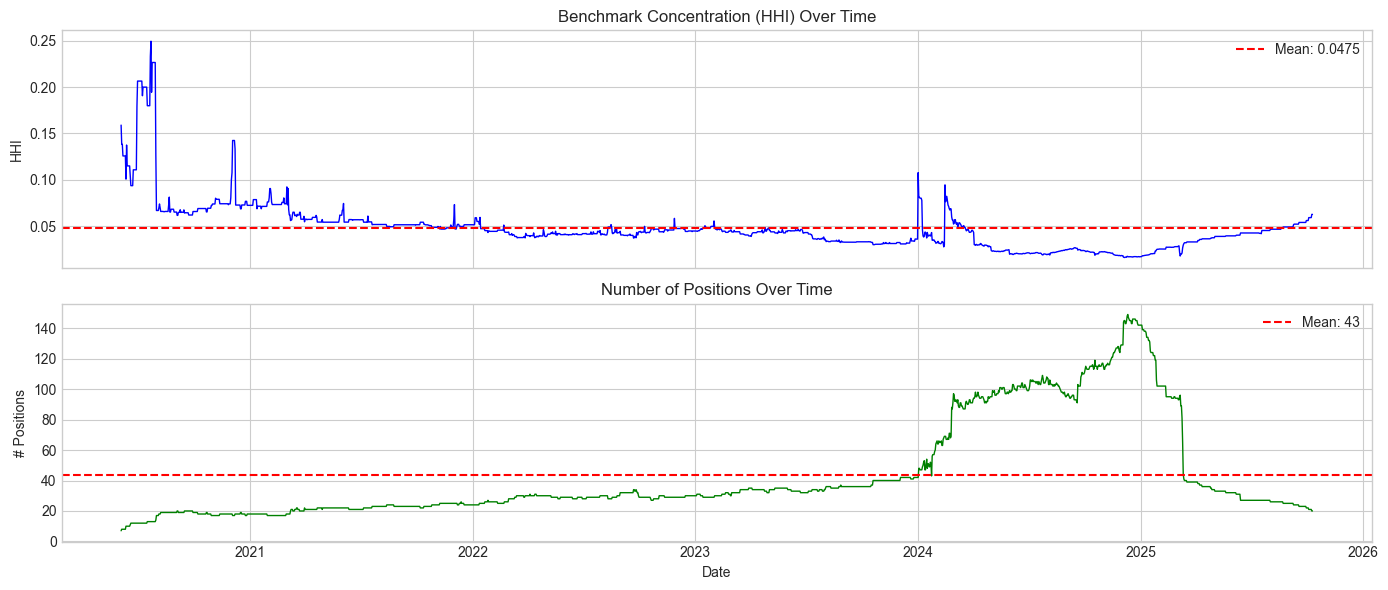

In [12]:
# Weight concentration over time
if bench_weights is not None:
    # HHI over time
    hhi_series = (bench_weights ** 2).sum(axis=1)
    
    # Number of positions over time
    n_positions = (bench_weights.abs() > 0.001).sum(axis=1)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    axes[0].plot(hhi_series.index, hhi_series.values, 'b-', linewidth=1)
    axes[0].axhline(y=hhi_series.mean(), color='red', linestyle='--', label=f'Mean: {hhi_series.mean():.4f}')
    axes[0].set_title('Benchmark Concentration (HHI) Over Time')
    axes[0].set_ylabel('HHI')
    axes[0].legend()
    
    axes[1].plot(n_positions.index, n_positions.values, 'g-', linewidth=1)
    axes[1].axhline(y=n_positions.mean(), color='red', linestyle='--', label=f'Mean: {n_positions.mean():.0f}')
    axes[1].set_title('Number of Positions Over Time')
    axes[1].set_ylabel('# Positions')
    axes[1].set_xlabel('Date')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

---
## 3. Asset Inference

Infer what underlying assets each algorithm trades.

In [13]:
from src.analysis.asset_inference import AssetInferenceEngine

# Check if benchmarks are available
print("Available benchmark directories:")
for subdir in ['forex', 'indices', 'commodities', 'futures', 'sharadar']:
    p = dp.raw.root / subdir
    if p.exists():
        n_files = len(list(p.glob('*')))
        print(f"  {subdir}/: {n_files} files")

Available benchmark directories:
  forex/: 170 files
  indices/: 10 files
  commodities/: 13 files
  futures/: 2 files
  sharadar/: 2 files


In [14]:
# Initialize asset inference engine using from_directory classmethod
try:
    engine = AssetInferenceEngine.from_directory(benchmarks_path)
    print(f"Loaded {len(engine.benchmarks)} benchmarks")
    
    # Group by asset class
    asset_classes = {}
    for name, meta in engine.bench_meta.items():
        asset_class = meta.get('asset_class', 'unknown')
        if asset_class not in asset_classes:
            asset_classes[asset_class] = []
        asset_classes[asset_class].append(name)
    
    print(f"Asset classes: {list(asset_classes.keys())}")
except Exception as e:
    print(f"Could not initialize asset inference: {e}")
    engine = None

Could not initialize asset inference: name 'benchmarks_path' is not defined


In [15]:
# Infer assets for sample algorithms
if engine is not None:
    sample_algos_for_inference = list(returns_sample.columns[:20])
    asset_inferences = {}
    
    print("Inferring assets for sample algorithms...")
    for algo_id in sample_algos_for_inference:
        algo_returns = returns_sample[algo_id].dropna()
        if len(algo_returns) > 50:
            try:
                # engine.infer() expects:
                #   algo_daily: DataFrame with 'close' column
                #   algo_returns: Series (optional)
                # Construct synthetic price series from returns
                close_prices = (1 + algo_returns).cumprod()
                algo_daily = pd.DataFrame({'close': close_prices})
                
                inference = engine.infer(algo_daily, algo_returns)
                asset_inferences[algo_id] = inference
            except Exception as e:
                print(f"  Error for {algo_id}: {e}")
    
    print(f"\nInferred assets for {len(asset_inferences)} algorithms")

In [16]:
# Display inference results
if engine is not None and asset_inferences:
    inference_df = pd.DataFrame([
        {
            'algo_id': algo_id,
            'predicted_asset': inf.predicted_asset,
            'asset_class': inf.asset_class,
            'direction': inf.direction,
            'confidence': inf.confidence,
            'best_composite': inf.best_composite,
        }
        for algo_id, inf in asset_inferences.items()
    ])
    
    print("Asset Inference Results:")
    display(inference_df)

In [17]:
# Asset class distribution
if engine is not None and asset_inferences:
    asset_class_counts = inference_df['asset_class'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Asset class pie chart
    axes[0].pie(asset_class_counts.values, labels=asset_class_counts.index, autopct='%1.1f%%')
    axes[0].set_title('Asset Class Distribution')
    
    # Confidence distribution
    axes[1].hist(inference_df['confidence'], bins=20, alpha=0.7, color='steelblue', edgecolor='white')
    axes[1].axvline(x=inference_df['confidence'].median(), color='red', linestyle='--', 
                    label=f'Median: {inference_df["confidence"].median():.0f}')
    axes[1].set_title('Inference Confidence Distribution')
    axes[1].set_xlabel('Confidence (%)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

---
## 4. Investment Clock Regime Inference

Infer business cycle regime from asset class performance patterns.

**Key Insight**: We use ASSET PERFORMANCE to infer regime (cause), NOT benchmark allocation (effect).

In [18]:
from src.analysis.latent_regime_inference import (
    InvestmentClockRegimeInference,
    BusinessCyclePhase,
)

# Only run if we have asset inferences
if engine is not None and asset_inferences:
    clock = InvestmentClockRegimeInference(rolling_window=21, vol_window=63)
    
    # Use the algorithms we have inferences for
    algos_with_inference = list(asset_inferences.keys())
    returns_for_clock = returns_sample[algos_with_inference]
    
    print(f"Running Investment Clock inference on {len(algos_with_inference)} algorithms...")
    clock_result = clock.infer_regime_from_assets(returns_for_clock, asset_inferences)
    print("Done.")
else:
    print("Skipping Investment Clock - need asset inferences first")
    clock_result = None

Skipping Investment Clock - need asset inferences first


In [19]:
# Display regime results
if clock_result is not None:
    print("BUSINESS CYCLE PHASES DETECTED")
    print("=" * 50)
    
    phase_names = {0: 'Recovery', 1: 'Expansion', 2: 'Slowdown', 3: 'Contraction'}
    
    for phase, stats in clock_result.phase_statistics.items():
        name = phase_names.get(phase, f'Phase {phase}')
        print(f"\n{phase}. {name}")
        print(f"   Days: {stats['n_days']} ({stats['pct_time']:.1f}%)")
        print(f"   Cyclical vs Defensive: {stats['avg_cyclical_vs_defensive']:.4f}")
        print(f"   Credit Spread: {stats['avg_credit_spread']:.4f}")
        print(f"   Volatility: {stats['avg_volatility']:.2%}")
        print(f"   Momentum Breadth: {stats['avg_momentum_breadth']:.1%}")

In [20]:
# Visualize regime over time
if clock_result is not None:
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    
    colors = {0: 'green', 1: 'blue', 2: 'orange', 3: 'red'}
    phase_names = {0: 'Recovery', 1: 'Expansion', 2: 'Slowdown', 3: 'Contraction'}
    
    # Regime labels over time
    regime_labels = clock_result.regime_labels
    for phase in regime_labels.unique():
        mask = regime_labels == phase
        axes[0].fill_between(regime_labels.index, 0, 1, where=mask, 
                            alpha=0.5, color=colors.get(phase, 'gray'),
                            label=phase_names.get(phase, f'Phase {phase}'))
    axes[0].set_title('Business Cycle Regime Over Time')
    axes[0].set_ylabel('Regime')
    axes[0].legend(loc='upper right')
    axes[0].set_ylim(0, 1)
    
    # Cyclical vs Defensive spread
    ind = clock_result.indicators
    axes[1].plot(ind.cyclical_vs_defensive.index, ind.cyclical_vs_defensive.values, 'b-', linewidth=1)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    axes[1].fill_between(ind.cyclical_vs_defensive.index, 0, ind.cyclical_vs_defensive.values,
                        where=ind.cyclical_vs_defensive.values > 0, alpha=0.3, color='green', label='Cyclicals winning')
    axes[1].fill_between(ind.cyclical_vs_defensive.index, 0, ind.cyclical_vs_defensive.values,
                        where=ind.cyclical_vs_defensive.values < 0, alpha=0.3, color='red', label='Defensives winning')
    axes[1].set_title('Cyclical vs Defensive Spread')
    axes[1].set_ylabel('Spread')
    axes[1].legend()
    
    # Volatility
    axes[2].plot(ind.volatility_level.index, ind.volatility_level.values, 'orange', linewidth=1)
    axes[2].axhline(y=ind.volatility_level.mean(), color='red', linestyle='--', 
                   label=f'Mean: {ind.volatility_level.mean():.2%}')
    axes[2].set_title('Cross-Sectional Volatility')
    axes[2].set_ylabel('Volatility')
    axes[2].legend()
    
    # Momentum Breadth
    axes[3].plot(ind.momentum_breadth.index, ind.momentum_breadth.values, 'purple', linewidth=1)
    axes[3].axhline(y=0.5, color='black', linestyle='--', linewidth=0.5)
    axes[3].fill_between(ind.momentum_breadth.index, 0.5, ind.momentum_breadth.values,
                        where=ind.momentum_breadth.values > 0.5, alpha=0.3, color='green')
    axes[3].fill_between(ind.momentum_breadth.index, 0.5, ind.momentum_breadth.values,
                        where=ind.momentum_breadth.values < 0.5, alpha=0.3, color='red')
    axes[3].set_title('Momentum Breadth (% of asset classes with positive momentum)')
    axes[3].set_ylabel('Breadth')
    axes[3].set_xlabel('Date')
    axes[3].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

In [21]:
# Transition matrix heatmap
if clock_result is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    phase_labels = ['Recovery', 'Expansion', 'Slowdown', 'Contraction']
    trans_matrix = clock_result.transition_matrix
    
    sns.heatmap(trans_matrix, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=phase_labels, yticklabels=phase_labels, ax=ax)
    ax.set_title('Regime Transition Probabilities')
    ax.set_xlabel('To Phase')
    ax.set_ylabel('From Phase')
    
    plt.tight_layout()
    plt.show()

---
## 5. Correlation Analysis

Analyze correlations between algorithms.

In [22]:
from src.analysis.correlation_analyzer import CorrelationAnalyzer

corr_analyzer = CorrelationAnalyzer()

# Use sample for visualization
corr_sample = returns_sample.iloc[:, :30]  # First 30 algorithms
print(f"Analyzing correlations for {len(corr_sample.columns)} algorithms...")

Analyzing correlations for 30 algorithms...


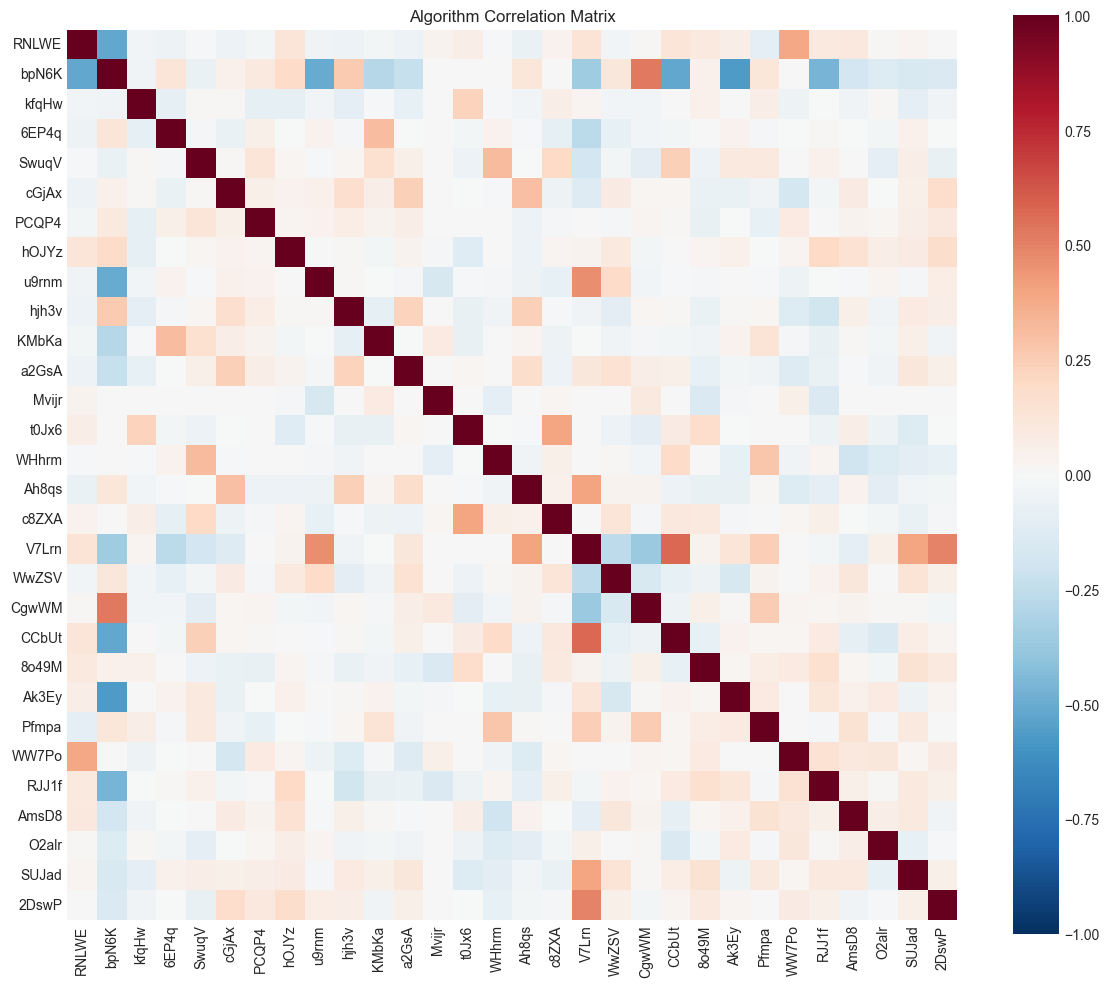

In [23]:
# Static correlation matrix
corr_matrix = corr_analyzer.correlation_matrix(corr_sample)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title('Algorithm Correlation Matrix')
plt.tight_layout()
plt.show()

In [24]:
# Correlation distribution
# Get upper triangle values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_values = corr_matrix.values[mask]
corr_values = corr_values[~np.isnan(corr_values)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(corr_values, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axvline(x=np.mean(corr_values), color='red', linestyle='--', label=f'Mean: {np.mean(corr_values):.3f}')
ax.axvline(x=np.median(corr_values), color='green', linestyle='--', label=f'Median: {np.median(corr_values):.3f}')
ax.set_title('Distribution of Pairwise Correlations')
ax.set_xlabel('Correlation')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Correlation Statistics:")
print(f"  Mean: {np.mean(corr_values):.4f}")
print(f"  Median: {np.median(corr_values):.4f}")
print(f"  Std: {np.std(corr_values):.4f}")
print(f"  % Negative: {(corr_values < 0).mean()*100:.1f}%")
print(f"  % Low (<0.3): {(np.abs(corr_values) < 0.3).mean()*100:.1f}%")

Correlation Statistics:
  Mean: 0.0100
  Median: 0.0000
  Std: 0.1226
  % Negative: 43.9%
  % Low (<0.3): 95.9%


In [25]:
# Diversification ratio
div_ratio = corr_analyzer.diversification_ratio(corr_sample)
print(f"Diversification Ratio (equal-weight): {div_ratio:.3f}")
print(f"  (>1 means diversification benefit exists)")

Diversification Ratio (equal-weight): 4.544
  (>1 means diversification benefit exists)


In [26]:
# Low correlation pairs
low_corr_pairs = corr_analyzer.get_low_correlation_pairs(corr_sample, threshold=0.2)
print(f"\nAlgorithm pairs with |correlation| < 0.2: {len(low_corr_pairs)}")
if low_corr_pairs:
    print("\nSample low-correlation pairs:")
    # get_low_correlation_pairs returns list of (algo1, algo2, correlation) tuples
    for pair in low_corr_pairs[:5]:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")


Algorithm pairs with |correlation| < 0.2: 402

Sample low-correlation pairs:
  bpN6K - Mvijr: 0.000
  bpN6K - t0Jx6: 0.000
  bpN6K - WHhrm: 0.000
  bpN6K - c8ZXA: 0.000
  bpN6K - WW7Po: 0.000


---
## 6. Summary

Key findings from Phase 2 analysis.

In [27]:
print("PHASE 2 ANALYSIS SUMMARY")
print("=" * 60)

print("\n1. ALGORITHM UNIVERSE")
print(f"   Total algorithms analyzed: {len(profiles)}")
print(f"   Median Sharpe: {summary_df['sharpe'].median():.2f}")
print(f"   Algorithms with Sharpe > 1: {(summary_df['sharpe'] > 1).sum()}")

print("\n2. BENCHMARK PROFILE")
print(f"   Annualized Return: {bench_profile.annualized_return:.2%}")
print(f"   Sharpe Ratio: {bench_profile.sharpe_ratio:.2f}")
print(f"   Max Drawdown: {bench_profile.max_drawdown:.2%}")
print(f"   Concentration (HHI): {bench_profile.concentration_hhi:.4f}")

if engine is not None and asset_inferences:
    print("\n3. ASSET INFERENCE")
    print(f"   Algorithms with inferred assets: {len(asset_inferences)}")
    print(f"   Asset classes found: {inference_df['asset_class'].nunique()}")
    print(f"   Median confidence: {inference_df['confidence'].median():.0f}%")

if clock_result is not None:
    print("\n4. BUSINESS CYCLE REGIMES")
    for phase, stats in clock_result.phase_statistics.items():
        name = {0: 'Recovery', 1: 'Expansion', 2: 'Slowdown', 3: 'Contraction'}.get(phase, f'Phase {phase}')
        print(f"   {name}: {stats['pct_time']:.1f}% of time")

print("\n5. CORRELATION STRUCTURE")
print(f"   Mean pairwise correlation: {np.mean(corr_values):.3f}")
print(f"   Diversification ratio: {div_ratio:.3f}")
print(f"   Low-correlation pairs: {len(low_corr_pairs)}")

PHASE 2 ANALYSIS SUMMARY

1. ALGORITHM UNIVERSE
   Total algorithms analyzed: 100
   Median Sharpe: 0.50
   Algorithms with Sharpe > 1: 21

2. BENCHMARK PROFILE
   Annualized Return: 2.59%
   Sharpe Ratio: 0.95
   Max Drawdown: -2.60%
   Concentration (HHI): 0.0626

5. CORRELATION STRUCTURE
   Mean pairwise correlation: 0.010
   Diversification ratio: 4.544
   Low-correlation pairs: 402


---
## Next Steps

With Phase 2 complete, you can now:
1. Use regime labels as features for RL agent
2. Build asset-class-aware allocation strategies
3. Implement baselines (equal weight, risk parity, etc.)
4. Design the RL environment